[![Ava Colabis](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adlerpriit/2025_taka_fall/blob/main/teemad/python/Seaborn.ipynb)

# Graafikud Seaborniga

Graafik aitab märgata jaotusi, seoseid ja rühmade erinevusi. Siin valid küsimusele sobiva graafiku, kujundad selle loetavaks ja selgitad tulemust.

**Eeldused:** oskad andmetabelit uurida, valida veerge ja teha rühmade kokkuvõtet; vajaduse korral korda [Pandase vihikut](Pandas.ipynb). Põhiosa on S1–S5 ja lõpuülesanne S-04. S6 on valikuline.

Seaborn joonistab Pandase tabeli põhjal. Matplotlibi abil lisad pealkirja, teljenimetused ja võrdlusjoone ning salvestad pildi. [Lahenduskäigud](lahendused/Seaborn_lahendused.md) on eraldi dokumendis.

Graafikut valides vaata [Data to Vizi](https://www.data-to-viz.com/) ülevaadet: alusta oma tunnuste tüüpidest ja küsimusest. [Python Graph Gallery Seaborni näited](https://python-graph-gallery.com/seaborn/) aitavad leida sobiva graafiku koodi; kohanda veerunimed ja selgita, mida graafik sinu andmetes näitab.

<a id="s1"></a>
## S1. Andmed ja joonise osad

Käivita andmete lugemise lahter. See vihik ei kasuta Pandase vihiku mälus olevaid muutujaid. Kohaliku faili puudumisel loetakse kursuse andmed veebist; kasutatud allikas kuvatakse.

`Diff` on pärast- ja enneskoori vahe. Positiivne väärtus tähendab suurenemist, negatiivne vähenemist. Rühmakoodid on `A` alprasolaam, `T` triasolaam ja `S` platseebo. Tegu on virtuaalsete katseisikute õppeandmetega. [Andmekirjeldus ja allikas](../../data/README.md).

In [1]:
# Teekide ja vajalike nimede importimine.
from pathlib import Path
import pandas as pd
from IPython.display import display

# Proovi esmalt repo juurkausta, seejärel töövihiku kausta suhtelist teed.
andmefail = Path("data/Islander_data.csv")
if not andmefail.is_file():
    andmefail = Path("../../data/Islander_data.csv")

if andmefail.is_file():
    allikas = andmefail
else:
    allikas = "https://raw.githubusercontent.com/adlerpriit/2025_taka_fall/37b50eb8474faeeb0993c2d4883680bee0560cbd/data/Islander_data.csv"

print("Andmete allikas:", allikas)
print("Pandase versioon:", pd.__version__)

# CSV lugemine Pandase tabeliks.
algandmed = pd.read_csv(allikas)
display(algandmed.head())

Andmete allikas: https://raw.githubusercontent.com/adlerpriit/2025_taka_fall/37b50eb8474faeeb0993c2d4883680bee0560cbd/data/Islander_data.csv
Pandase versioon: 2.2.3


,first_name,last_name,age,Happy_Sad_group,Dosage,Drug,Mem_Score_Before,Mem_Score_After,Diff
0,Bastian,Carrasco,25,H,1,A,63.5,61.2,-2.3
1,Evan,Carrasco,52,S,1,A,41.6,40.7,-0.9
2,Florencia,Carrasco,29,H,1,A,59.7,55.1,-4.6
3,Holly,Carrasco,50,S,1,A,51.7,51.2,-0.5
4,Justin,Carrasco,52,H,1,A,47.0,47.1,0.1


In [2]:
# Joonistamiseks vajalike teekide importimine.
import matplotlib.pyplot as plt
import seaborn as sns

# Graafikute ühise kujunduse määramine.
sns.set_theme(style="whitegrid", palette="colorblind")

# Keskkonna ja andmete kontroll enne joonistamist.
print("Seaborni versioon:", sns.__version__)
print("Ridu ja veerge:", algandmed.shape)
display(algandmed[["age", "Mem_Score_Before", "Mem_Score_After", "Diff"]].describe())

Seaborni versioon: 0.13.2
Ridu ja veerge: (198, 9)


,age,Mem_Score_Before,Mem_Score_After,Diff
count,198.000000,198.000000,198.000000,198.000000
mean,39.530303,57.967677,60.922222,2.954545
std,12.023099,15.766007,18.133851,10.754603
min,24.000000,27.200000,27.100000,-40.400000
25%,30.000000,46.525000,47.175000,-3.175000
50%,37.000000,54.800000,56.750000,1.700000
75%,48.000000,68.400000,73.250000,5.925000
max,83.000000,110.000000,120.000000,49.000000


Enne joonistamist kontrolli tunnuste tähendust ja väärtuste vahemikke. Ühe lähterea kohta on üks katseisikukirje.

Tavaline joonistamise muster on:

1. `fig, ax = plt.subplots(...)` loob joonise (`fig`) ja joonistusala (`ax`). Python jaotab kaks tagastatud objekti kahe muutuja vahel.
2. Seaborni funktsioon saab tabeli `data=...` ning veerunimed `x=...` ja `y=...` kaudu.
3. `ax=ax` määrab joonistusala. `ax.set()` seab pealkirja ja teljenimetused.
4. `fig.tight_layout()` kohandab paigutust, `plt.show()` kuvab joonise.

Dokumentatsioon: [subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html).

<a id="s2"></a>
## S2. Punktdiagramm: kahe arvtunnuse seos

Küsimus: kuidas seostuvad vanus ja skoori muutus? Punktdiagrammis tähistab üks punkt üht kirjet. Esmalt joonista ainult kaks tunnust.

Dokumentatsioon: [scatterplot](https://seaborn.pydata.org/generated/seaborn.scatterplot.html).

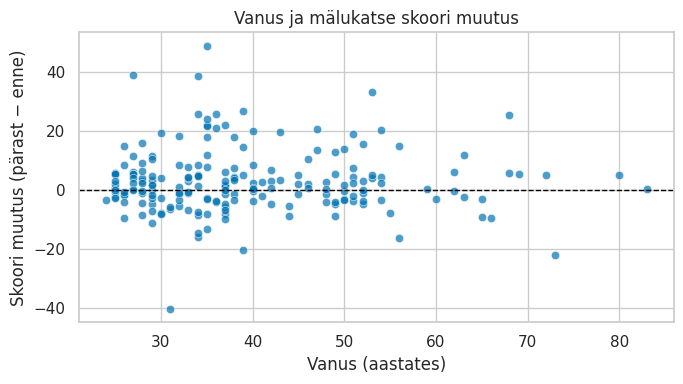

In [3]:
# Joonise ja joonistusala loomine.
fig, ax = plt.subplots(figsize=(7, 4))

# Seaborn: punktdiagramm kahe arvtunnuse võrdlemiseks.
sns.scatterplot(data=algandmed, x="age", y="Diff", alpha=0.7, ax=ax)

# Matplotlib: nulljoon muutuse puudumise tähistamiseks.
ax.axhline(0, color="black", linestyle="--", linewidth=1)

# Pealkirja ja teljenimetuste määramine.
ax.set(title="Vanus ja mälukatse skoori muutus", xlabel="Vanus (aastates)", ylabel="Skoori muutus (pärast − enne)")
fig.tight_layout()
plt.show()

Katkendjoon näitab muutuse puudumist. `alpha` määrab punktide läbipaistvuse ja aitab näha kattumist.

Lisa värviga üks rühmitus: `hue="Drug"`. Seaborn loob vastava legendi. Selges graafikus peavad värv ja legend tähistama samu rühmi.

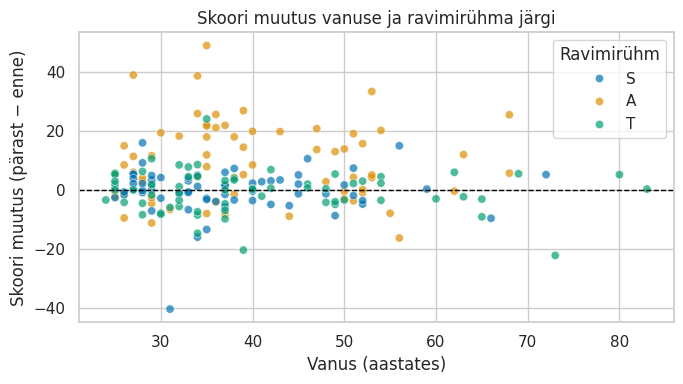

In [4]:
# Punktdiagramm: hue eristab ravimirühmi värviga.
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=algandmed, x="age", y="Diff", hue="Drug", hue_order=["S", "A", "T"], alpha=0.7, ax=ax)

# Võrdlusjoone lisamine.
ax.axhline(0, color="black", linestyle="--", linewidth=1)

# Pealkirja, teljenimetuste ja legendi kujundamine.
ax.set(title="Skoori muutus vanuse ja ravimirühma järgi", xlabel="Vanus (aastates)", ylabel="Skoori muutus (pärast − enne)")
ax.legend(title="Ravimirühm")
fig.tight_layout()
plt.show()

<a id="s-01"></a>

### Ülesanne S-01

Joonista punktdiagramm: x-teljel `Mem_Score_Before`, y-teljel `Mem_Score_After`, värviks `Drug`. Lisa arusaadav pealkiri, teljenimetused ja legend. Kirjelda ühe lausega, mida üks punkt tähendab.

**Enesekontroll:** kas teljed on õiges järjekorras ja kõik ravimirühmad legendis? Millises piirkonnas asuvad kirjed, mille pärast-skoor on enne-skoorist suurem?

**Lisavõte:** lisa soovi korral joon `y = x`. Sellel joonel on enne- ja pärast-skoor võrdsed, seega tähistab see muutuse puudumist.

Leia kahe skooriveeru peale väikseim väärtus ja salvesta see muutujasse `alumine`; suurim väärtus salvesta muutujasse `ylemine`. Lisa enne `plt.show()` käsku `ax.plot([alumine, ylemine], [alumine, ylemine], color="black", linestyle="--")`.

Esimene list annab joone otspunktide x-koordinaadid, teine y-koordinaadid. Kuna listid on samad, ühendab joon punktid `(alumine, alumine)` ja `(ylemine, ylemine)`. Nii ulatub joon väikseimast skoorist suurimani.

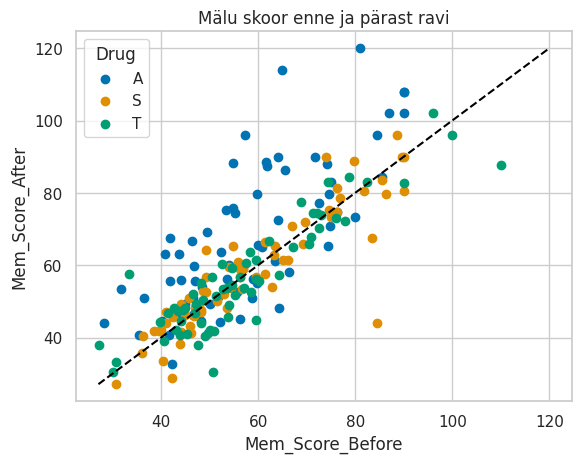

In [5]:
# Kirjuta siia oma kood. Vajaduse korral lisa lahtreid.
fig, ax = plt.subplots()

for ravim in algandmed["Drug"].unique():
    andmed = algandmed[algandmed["Drug"] == ravim]
    ax.scatter(
        andmed["Mem_Score_Before"],
        andmed["Mem_Score_After"],
        label=ravim
    )

ax.set_title("Mälu skoor enne ja pärast ravi")
ax.set_xlabel("Mem_Score_Before")
ax.set_ylabel("Mem_Score_After")
ax.legend(title="Drug")

alumine = algandmed[["Mem_Score_Before", "Mem_Score_After"]].min().min()
ylemine = algandmed[["Mem_Score_Before", "Mem_Score_After"]].max().max()

ax.plot([alumine, ylemine], [alumine, ylemine],color="black", linestyle="--")
plt.show()

Üks punkt tähistab ühte osalejat: x-koordinaat näitab tema mälu skoori enne ravi, y-koordinaat pärast ravi ning punkti värv näitab ravimirühma.

Punktid, mille Mem_Score_After on suurem kui Mem_Score_Before, asuvad joonest y = x ülevalpool. Punkt joonel tähendab, et enne- ja pärast-skoor on võrdsed.

<a id="s3"></a>
## S3. Histogramm: ühe tunnuse jaotus

Histogrammis on x-teljel väärtuste vahemikud ja y-teljel nende vahemike vaatluste arv. Iga tulp koondab mitu kirjet. `bins` määrab vahemike arvu; selle muutmine võib jaotuse ilmet muuta.

Dokumentatsioon: [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html).

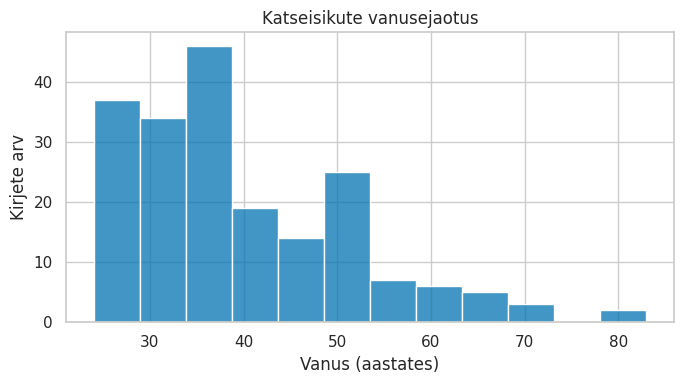

In [6]:
# Histogramm: bins määrab väärtuste vahemike arvu.
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=algandmed, x="age", bins=12, ax=ax)

# Pealkirja ja teljenimetuste määramine.
ax.set(title="Katseisikute vanusejaotus", xlabel="Vanus (aastates)", ylabel="Kirjete arv")
fig.tight_layout()
plt.show()

<a id="s-02"></a>

### Ülesanne S-02

Koosta `Diff` histogramm esmalt 10 ja seejärel 20 vahemikuga. Lisa nulli juurde vertikaaljoon `ax.axvline(0, ...)`. Kirjelda üht jaotuse omadust, mida näed mõlemas variandis.

**Enesekontroll:** tulba kõrgus näitab kirjete arvu, mitte keskmist skoori. Selgita, miks vahemike arvu muutmine ei muuda algandmeid.

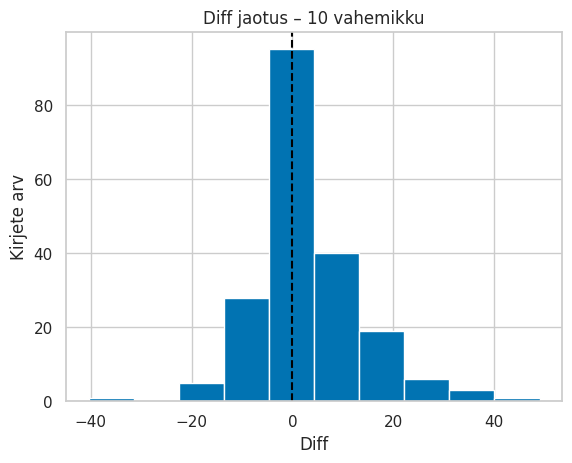

In [7]:
# Kirjuta siia oma kood. Vajaduse korral lisa lahtreid.
fig, ax = plt.subplots()
ax.hist(algandmed["Diff"], bins=10)
ax.axvline(0, color="black", linestyle="--")
ax.set_title("Diff jaotus – 10 vahemikku")
ax.set_xlabel("Diff")
ax.set_ylabel("Kirjete arv")
plt.show()

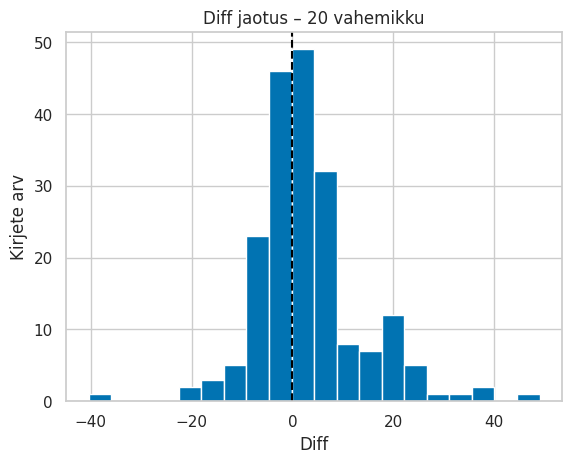

In [8]:
fig, ax = plt.subplots()
ax.hist(algandmed["Diff"], bins=20)
ax.axvline(0, color="black", linestyle="--")
ax.set_title("Diff jaotus – 20 vahemikku")
ax.set_xlabel("Diff")
ax.set_ylabel("Kirjete arv")
plt.show()

Mõlemas histogrammis on näha, kuidas Diff väärtused jaotuvad nulli suhtes. Saab vaadelda, kas suurem osa väärtustest paikneb nullist paremal või vasakul.

Vahemike arvu muutmine ei muuda algandmeid, vaid ainult seda, kuidas samad väärtused histogrammis rühmadesse ehk vahemikesse jaotatakse. 10 vahemiku korral on vahemikud ja tulbad laiemad, 20 vahemiku korral on vahemikud kitsamad. Tulba kõrgus näitab, mitu kirjet vastavasse vahemikku kuulub.

<a id="s4"></a>
## S4. Rühmade võrdlemine

Kastdiagramm näitab arvulise tunnuse jaotust rühmade kaupa. Kasti sees olev joon on mediaan. Kast ulatub alumisest ülemise kvartiilini ja sisaldab jaotuse keskmist poolt. Vurrud ulatuvad siin äärmiste vaatlusteni, mis jäävad kuni 1,5 kvartiilivahe kaugusele kastist. Kaugemad vaatlused kuvatakse eraldi punktidena; need ei ole automaatselt andmevead.

Võrdle lisaks asukohale ka jaotuste laiust. Ainult rühma keskmine peidaks osa sellest infost.

Dokumentatsioon: [boxplot](https://seaborn.pydata.org/generated/seaborn.boxplot.html).

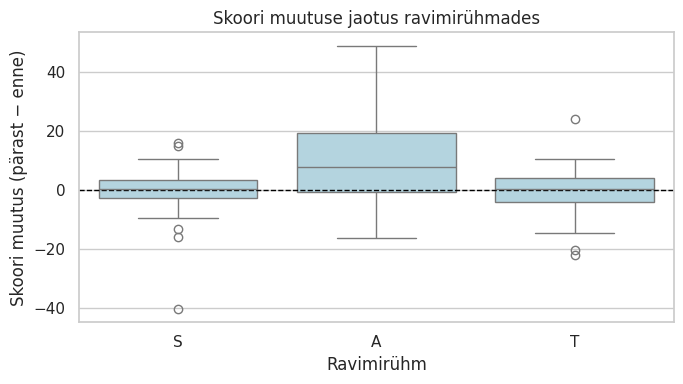

In [9]:
# Kastdiagramm: skoori muutuse jaotused ravimirühmades.
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=algandmed, x="Drug", y="Diff", order=["S", "A", "T"], color="lightblue", ax=ax)

# Nulljoone lisamine muutuse puudumise tähistamiseks.
ax.axhline(0, color="black", linestyle="--", linewidth=1)

# Pealkirja ja teljenimetuste määramine.
ax.set(title="Skoori muutuse jaotus ravimirühmades", xlabel="Ravimirühm", ylabel="Skoori muutus (pärast − enne)")
fig.tight_layout()
plt.show()

<a id="s-03"></a>

### Ülesanne S-03

Vaata eelmist kastdiagrammi ja vasta:

1. Millise rühma mediaan on suurim? Millises rühmas paistab jaotus kõige laiem?
2. Mida oleksid kaotanud, kui kuvanuksid ainult rühmade keskmised?
3. Kas graafik üksi tõestab, et ravim põhjustab skoori muutuse? Põhjenda.

**Enesekontroll:** erista mediaani, keskmist ja üksikvaatlust. Vajaduse korral kontrolli arvulist väidet Pandase rühmitusega.

1. T rühma mediaan on suurim. Jaotus on kõige suurem rühmas A.
2. Keskmine annab ühe väärtuse iga rühma kohta, kuid ei näitaks mediaani, hajuvust või vahemikku. Kastdiagramm näitab neid paremini.
3. Graafik üksi ei tõesta põhjuslikkust. Kastdiagramm näitab kuidas Diff jaotub erinevates ravimirühmades, kuid erinevus ei tähenda veel, et selle põhjustas ravim. Mõned muud tegurid võivad ka seda mõjutada, nt osalejate erinevused.

<a id="s5"></a>
## S5. Joonise salvestamine

Määra joonise loomisel `figsize=(laius, kõrgus)` **tollides** (1 toll = 2,54 cm). Ühe lihtsa graafiku jaoks sobib lähtepunktiks `(7, 4)` ehk umbes 18 × 10 cm. Kui teljenimetused või legend ei mahu ära, suurenda vastavat mõõdet. Kontrolli teksti loetavust selles suuruses, milles joonist kasutad.

Salvestamiseks kasuta selle joonise `fig`-objekti. PNG-faili puhul määrab `dpi` pikslite arvu tolli kohta: **mõõt pikslites = mõõt tollides × DPI**. Ekraanil kasutamiseks alusta vahemikust 100–150 DPI, trükiks on tavapärane lähtepunkt 300 DPI. Suurem DPI lisab piksleid ja kasvatab faili mahtu, kuid ei muuda teksti graafiku suhtes suuremaks.

Näites annab 7 × 4 tolli ja 150 DPI pildi mõõtmetega **1050 × 600 pikslit enne servade kärpimist**. `bbox_inches="tight"` vähendab liigseid servi, mistõttu salvestatud pildi täpsed mõõtmed võivad erineda.

Dokumentatsioon: [joonise mõõtühikud](https://matplotlib.org/stable/gallery/subplots_axes_and_figures/figure_size_units.html), [Figure.savefig](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html).

Salvestatud: /content/valjund/skoori_muutuse_jaotus.png


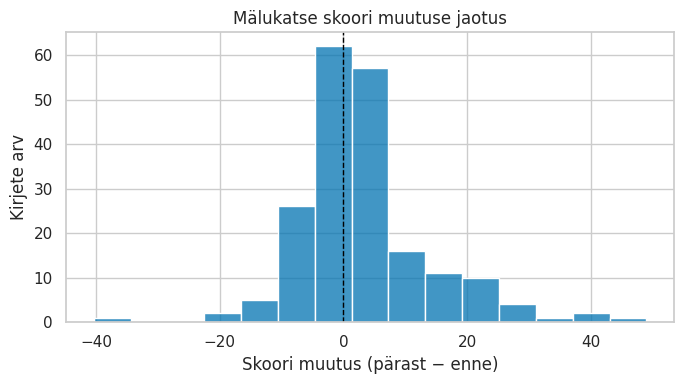

In [10]:
# Joonise mõõtmed: laius 7 tolli, kõrgus 4 tolli.
# Histogrammi koostamine.
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=algandmed, x="Diff", bins=15, ax=ax)

# Võrdlusjoone, pealkirja ja teljenimetuste lisamine.
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set(title="Mälukatse skoori muutuse jaotus", xlabel="Skoori muutus (pärast − enne)", ylabel="Kirjete arv")
fig.tight_layout()

# Pildifaili asukoha määramine.
kaust = Path("valjund")
kaust.mkdir(exist_ok=True)
pildifail = kaust / "skoori_muutuse_jaotus.png"

# PNG salvestamine: 150 DPI annab enne servade kärpimist 1050 × 600 pikslit.
fig.savefig(pildifail, dpi=150, bbox_inches="tight")
print("Salvestatud:", pildifail.resolve())

# Joonise kuvamine töövihikus.
plt.show()

Enne graafiku jagamist kontrolli: millisele küsimusele see vastab, mida üks märk tähendab, kas ühikud ja rühmad on arusaadavad ning kas tekst on loetav. Värv ei pea olema ainus viis rühmade eristamiseks: kategooriatelg ja legend aitavad samuti.

<a id="l-01"></a>
<a id="s-04"></a>

### Ülesanne S-04. Lõpuülesanne

Vali üks küsimus:

- Kuidas erineb skoori muutuse jaotus ravimirühmade vahel?
- Kuidas erineb skoori muutuse jaotus rõõmsate ja kurbade mälestuste rühmas?

Tee oma lahtris järgmised sammud.

1. Loo `algandmed` põhjal töökoopia. Kontrolli ridade arvu ja vajalike veergude puuduvaid väärtusi.
2. Arvuta uus veerg `muutus = Mem_Score_After − Mem_Score_Before`. Veendu, et see vastab `Diff`-ile; kümnendarvude võrdluses võib olla väike ümarduserinevus.
3. Koosta valitud rühmade kokkuvõte: keskmine muutus ja ridade arv.
4. Joonista sama tunnuse jaotus valitud rühmades. Lisa pealkiri, teljenimetused ja vajaduse korral legend.
5. Salvesta kokkuvõte ja graafik kausta `esitus` nimedega `kokkuvote.csv` ja `graafik.png`.
6. Kirjuta 2–4 lauset: mida võrdlesid, mida tabel ja graafik näitavad ning millist järeldust nende põhjal teha ei saa.

**Enesekontroll:** rühmade ridade arvu summa vastab analüüsitabelile; graafik kasutab samu ridu ja rühmi kui kokkuvõte. Taaskäivita kernel ja käivita kogu põhiosa. Töö peab toimima ka siis, kui lisamaterjal jääb vahele.

Lisa oma reposse täidetud töövihik, `esitus/kokkuvote.csv` ja `esitus/graafik.png`. Õige lahendus võib näidislahendusest erineda, kui kood töötab ja oskad tulemust selgitada.

Ridade arv: 198

Puuduvad väärtused:
Drug                0
Mem_Score_Before    0
Mem_Score_After     0
Diff                0
dtype: int64
Analüüsitavate ridade arv: 198
Kas muutus ja Diff langevad kokku:
1.1379786002407855e-14


,keskmine_muutus,ridade_arv
Drug,,
A,9.470149,67
S,-0.171212,66
T,-0.587692,65


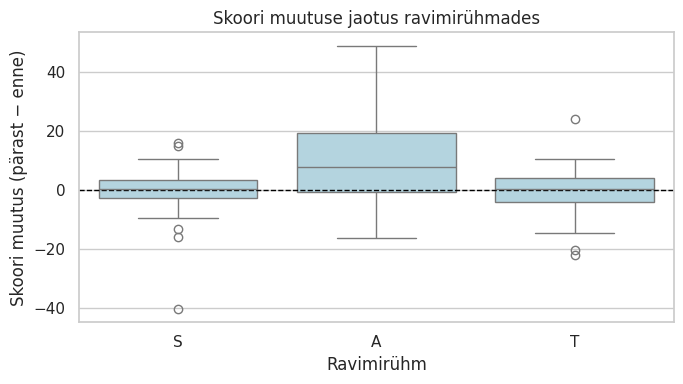

In [11]:
# Kirjuta siia oma kood. Vajaduse korral lisa lahtreid.
import os
andmed = algandmed.copy()

print("Ridade arv:", len(andmed))

print("\nPuuduvad väärtused:")
print(andmed[["Drug", "Mem_Score_Before", "Mem_Score_After", "Diff"]].isna().sum())

andmed = andmed.dropna(subset=["Drug", "Mem_Score_Before", "Mem_Score_After"]).copy()
print("Analüüsitavate ridade arv:", len(andmed))

andmed["muutus"] = (andmed["Mem_Score_After"] - andmed["Mem_Score_Before"])

print("Kas muutus ja Diff langevad kokku:")
print((andmed["muutus"] - andmed["Diff"]).abs().max())

kokkuvote = andmed.groupby("Drug").agg(keskmine_muutus=("muutus", "mean"), ridade_arv=("muutus", "count"))
display(kokkuvote)

assert kokkuvote["ridade_arv"].sum() == len(andmed)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=andmed, x="Drug", y="muutus", order=["S", "A", "T"], color="lightblue", ax=ax)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Skoori muutuse jaotus ravimirühmades")
ax.set_xlabel("Ravimirühm")
ax.set_ylabel("Skoori muutus (pärast − enne)")
fig.tight_layout()
plt.show()

os.makedirs("esitus", exist_ok=True)
kokkuvote.to_csv("esitus/kokkuvote.csv")
fig.savefig("esitus/graafik.png", dpi=300, bbox_inches="tight")

Võrdlesin skoori muutuse (Mem_Score_After - Mem_Score_Before) jaotust ravimirühmade S, A ja T vahel. Tabel näitab iga rühma keskmist muutust ja analüüsitud kirjete arvu ning kastdiagramm näitab muutuste mediaani, hajuvust ja võimalikke erinevusi. Rühmade erinevus näitab, et skoori muutuse jaotused ei pruugi olla samasugused, kuid ainult selle tabeli ja graafiku põhjal ei saa järeldada, et erinevuse põhjustas ravim.

Põhiosa lõpeb siin. Võrdle oma tööd [lahenduskäikudega](lahendused/Seaborn_lahendused.md), kui oled ise proovinud. Allolev lisamaterjal ei kuulu kohustusliku lõpuülesande eelduste hulka.

<a id="s6"></a>
## S6. Lisamaterjal: üks paneel iga rühma kohta

`sns.relplot()` loob ise terve joonise koos paneelidega. Sellele ei anta `ax=` argumenti. Tagastatud objekt `g` haldab joonist ja paneele; `g.axes` sisaldab joonistusalasid. `col="Drug"` paigutab ravimirühmad eri paneelidesse.

Ühised teljepiirid aitavad paneele võrrelda. Võrdsusjoon näitab, kus enne- ja pärastmõõtmine on samad. `.flat` võimaldab kõik joonistusalad ühe tsükliga läbi käia.

Dokumentatsioon: [relplot](https://seaborn.pydata.org/generated/seaborn.relplot.html).

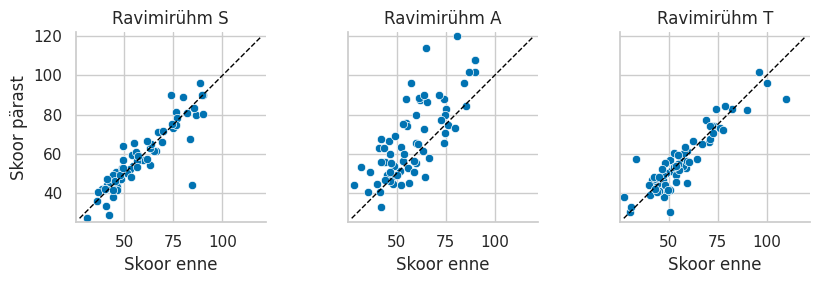

In [12]:
# Mõlemale teljele ühiste piiride leidmine.
piirid = algandmed[["Mem_Score_Before", "Mem_Score_After"]]
alumine = piirid.min().min()
ylemine = piirid.max().max()

# relplot(): iga ravimirühm eraldi paneelis.
g = sns.relplot(
    data=algandmed, x="Mem_Score_Before", y="Mem_Score_After",
    col="Drug", col_order=["S", "A", "T"], kind="scatter", height=3, aspect=1,
)

# Võrdsusjoone ja sama skaala lisamine kõigile paneelidele.
for ax in g.axes.flat:
    ax.plot([alumine, ylemine], [alumine, ylemine], color="black", linestyle="--", linewidth=1)
    ax.set(xlim=(alumine - 2, ylemine + 2), ylim=(alumine - 2, ylemine + 2))
    ax.set_aspect("equal", adjustable="box")

# Teljenimetuste ja paneelide pealkirjade määramine.
g.set_axis_labels("Skoor enne", "Skoor pärast")
g.set_titles("Ravimirühm {col_name}")
plt.show()

<a id="s-l1"></a>
<a id="s-l01"></a>

### Lisaülesanne S-L01

Tee sarnane paneelidega punktdiagramm, kus paneelid eristavad `Happy_Sad_group` väärtusi. Lisa värviga ravimirühm.

**Enesekontroll:** paneele peab olema kaks ning telgede skaala peab võimaldama neid võrrelda. Selgita, millist võrdlust paneelid hõlbustavad.

In [13]:
# Kirjuta siia oma kood. Vajaduse korral lisa lahtreid.

*Kirjuta siia oma vastus või põhjendus.*

## Edasi lugemiseks

- [Seaborni juhend](https://seaborn.pydata.org/tutorial.html) — vali üks graafikutüüp ja katseta üht lisaparameetrit.
- [Joonistusfunktsioonide erinevused](https://seaborn.pydata.org/tutorial/function_overview.html) — millal kasutada `ax` ja millal Seaborni loodud tervet joonist.
- [Veapiiride tähendus](https://seaborn.pydata.org/tutorial/error_bars.html) — enne `errorbar` kasutamist erista hajuvust ja keskmise määramatust. `"sd"` tähistab standardhälvet, `"se"` standardviga ja `"ci"` usaldusvahemikku.
- [Matplotlibi `savefig`](https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html) — faili vorming ja salvestamise sätted.

Üks graafik ei tõesta põhjuslikku mõju. Järelduse ulatus peab vastama andmetele ja kasutatud analüüsile.